In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()



True

In [3]:
class SubState(TypedDict):
    input_text: str
    translated_text: str 

In [4]:
subgraph_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0, 
    max_tokens=None,
    timeout=None,
    max_retries=2,
) 

In [5]:
def translate_text(state : SubState):

    prompt = f"""
    Translate the following text to hindi keep it natural and clear do not add any other extra content

    Text : {state["input_text"]}

    """.strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)
subgraph_builder.add_node('translate_text' , translate_text)

subgraph_builder.add_edge(START , 'translate_text')
subgraph_builder.add_edge('translate_text' , END )

subgraph = subgraph_builder.compile()



In [7]:
class ParentState(TypedDict):
    question : str 
    answer_eng: str 
    answer_hin : str 
    


In [8]:
parent_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0, 
    max_tokens=None,
    timeout=None,
    max_retries=2,
) 

In [9]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(
        f"you are a helpful assistant . answer clearly. \n \n Question : {state['question']}"
    ).content


    return {'answer_eng': answer}
    



In [10]:
def translate_answer(state : ParentState):
    # call the subgraph here
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return{'answer_hin': result['translated_text']}

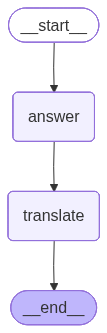

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START , 'answer')
parent_builder.add_edge('answer' , 'translate')
parent_builder.add_edge( 'translate' , END)

graph = parent_builder.compile()

graph


In [12]:
graph.invoke({'question' : "What is quantum Physics"})

{'question': 'What is quantum Physics',
 'answer_eng': 'Quantum Physics (also known as Quantum Mechanics or Quantum Theory) is the branch of physics that studies the **behavior of matter and energy at the most fundamental, atomic, and subatomic levels.**\n\nHere\'s a breakdown to help you understand it clearly:\n\n1.  **The World of the Very, Very Small:**\n    *   Classical physics (the physics we experience daily, like gravity, motion of cars, etc.) works great for large objects. However, when you go down to the scale of atoms, electrons, photons, and other tiny particles, classical physics completely breaks down.\n    *   Quantum physics provides a new set of rules to describe how these incredibly small particles behave.\n\n2.  **Key Concepts and Why it\'s "Weird":**\n\n    *   **Quantization:** Energy, momentum, and other properties are not continuous but come in discrete, indivisible packets called "quanta." For example, light isn\'t a continuous stream of energy but comes in tiny

In [13]:
graph.invoke({'question' : "What are the use cases of PyTorch"})

{'question': 'What are the use cases of PyTorch',
 'answer_eng': "PyTorch is a popular open-source machine learning library primarily used for deep learning applications. Its flexibility, Pythonic interface, and dynamic computational graph make it incredibly versatile for a wide range of use cases, from academic research to production deployment.\n\nHere are the primary use cases of PyTorch:\n\n1.  **Computer Vision:**\n    *   **Image Classification:** Identifying the main object or category within an image (e.g., dog, cat, car).\n    *   **Object Detection:** Locating and identifying multiple objects within an image, drawing bounding boxes around them (e.g., detecting pedestrians and traffic signs in autonomous driving).\n    *   **Image Segmentation:** Assigning a label to every pixel in an image, allowing for precise object boundaries (e.g., medical image analysis, background removal).\n    *   **Image Generation/Modification:** Creating new images or altering existing ones using G